<a href="https://colab.research.google.com/github/UH-GROUP-X/Hackathon26/blob/main/UH_GROUP_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hackathon 2026

# Setup file path and install packages

In [ ]:
# To get the training dataset from the Github.

import pandas as pd
datapath1 = "https://raw.githubusercontent.com/UH-GROUP-X/Hackathon26/refs/heads/main/dataset_C_training.csv"
df1 = pd.read_csv(datapath1)
df1.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,chronic_med_condition,child_under_6_months,health_worker,health_insurance,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,NaN,45 - 54 Years,12 Years,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,45 - 54 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,65+ Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [ ]:
# To get the testing dataset from the Github.

import pandas as pd
datapath2 = "https://raw.githubusercontent.com/UH-GROUP-X/Hackathon26/refs/heads/main/dataset_C_testing.csv"
df2 = pd.read_csv(datapath2)
df2.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,chronic_med_condition,child_under_6_months,health_worker,health_insurance,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector
0,4757,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,65+ Years,12 Years,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,0,4,2,2.0,NaN
1,4758,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,65+ Years,NaN,White,Female,NaN,NaN,NaN,NaN,"MSA, Not Principle City",0.0,0.0,0,2,3,2.0,NaN
2,4759,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,65+ Years,College Graduate,White,Male,NaN,Married,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,0,3,2,2.0,NaN
3,4760,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,55 - 64 Years,12 Years,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,1.0,0.0,0,4,4,1.0,agriculture
4,4761,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,35 - 44 Years,Some College,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,Non-MSA,0.0,0.0,0,3,2,1.0,wholesale


In [ ]:
# To mount the google drive to later use it for saving the files.

from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted


In [ ]:
!pip install -q xgboost lightgbm shap imbalanced-learn

# 1. Configuration

In [ ]:
# Configration for the submission files.

DRIVE_ROOT = '/content/drive/MyDrive/'
DATA_FOLDER = 'hackathon/'
SUBMISSION_DIR = DRIVE_ROOT + DATA_FOLDER + 'submissions/'

# To define the target and other variables.
TARGET_COL = 'covid_vaccine'
ID_COL = 'respondent_id'
TASK = 'classification'
RANDOM_STATE = 42

TRAIN_PATH = df1 # train
TEST_PATH  = df2 # test
SUBMISSION_DIR = DRIVE_ROOT + DATA_FOLDER + 'submissions/'
GROUP_NUMBER = 'X'

import os
os.makedirs(SUBMISSION_DIR, exist_ok=True)

print(f'Train      : {TRAIN_PATH}')
print(f'Test       : {TEST_PATH}')
print(f'Submissions: {SUBMISSION_DIR}')
print(f'Group      : {GROUP_NUMBER}')

Train      :       respondent_id  covid_concern  covid_knowledge  \
0                 1            3.0              1.0   
1                 2            2.0              1.0   
2                 3            0.0              2.0   
3                 4            2.0              2.0   
4                 5            1.0              1.0   
...             ...            ...              ...   
4751           4752            0.0              1.0   
4752           4753            2.0              1.0   
4753           4754            3.0              2.0   
4754           4755            1.0              2.0   
4755           4756            1.0              2.0   

      behavioral_antiviral_meds  behavioral_avoidance  behavioral_face_mask  \
0                           0.0                   1.0                   0.0   
1                           0.0                   1.0                   0.0   
2                           0.0                   0.0                   0.0   
3         

# 2. Imports

In [ ]:
# To import all the important libraries.

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

# libraries for the Pre-processing.
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import ( StandardScaler, RobustScaler, LabelEncoder,
                                    OneHotEncoder, OrdinalEncoder)

# To import all the Models.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# For Evaluation.
from sklearn.model_selection import ( train_test_split, cross_val_score,
                                      StratifiedKFold, RandomizedSearchCV)
from sklearn.metrics import ( accuracy_score, f1_score, roc_auc_score,
                              precision_score, recall_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

# For XAI.
import shap

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
pd.set_option('display.max_columns', 40)

# 3. Load data

In [ ]:
# To load the data.

train_raw = pd.read_csv(datapath1)
test_raw  = pd.read_csv(datapath2)

print(f'Train : {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns')
print(f'Test  : {test_raw.shape[0]:,} rows × {test_raw.shape[1]} columns')
train_raw.head()

Train : 4,756 rows × 31 columns
Test  : 4,749 rows × 30 columns


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,chronic_med_condition,child_under_6_months,health_worker,health_insurance,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,NaN,45 - 54 Years,12 Years,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,45 - 54 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,65+ Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


# 4. Exploratory Data Analysis (EDA)

In [ ]:
# To get the overview.

train_raw.info()
print()
display(train_raw.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   respondent_id                 4756 non-null   int64  
 1   covid_concern                 4744 non-null   float64
 2   covid_knowledge               4729 non-null   float64
 3   behavioral_antiviral_meds     4742 non-null   float64
 4   behavioral_avoidance          4729 non-null   float64
 5   behavioral_face_mask          4754 non-null   float64
 6   behavioral_wash_hands         4747 non-null   float64
 7   behavioral_large_gatherings   4746 non-null   float64
 8   behavioral_outside_home       4742 non-null   float64
 9   behavioral_touch_face         4735 non-null   float64
 10  chronic_med_condition         4587 non-null   float64
 11  child_under_6_months          4621 non-null   float64
 12  health_worker                 4624 non-null   float64
 13  hea

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
respondent_id,4756.0,NaN,NaN,NaN,2378.5,1373.08327,1.0,1189.75,2378.5,3567.25,4756.0
covid_concern,4744.0,NaN,NaN,NaN,1.648609,0.903204,0.0,1.0,2.0,2.0,3.0
covid_knowledge,4729.0,NaN,NaN,NaN,1.296469,0.615705,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4742.0,NaN,NaN,NaN,0.053353,0.22476,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4729.0,NaN,NaN,NaN,0.733347,0.442256,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4754.0,NaN,NaN,NaN,0.072991,0.260149,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4747.0,NaN,NaN,NaN,0.839267,0.367323,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4746.0,NaN,NaN,NaN,0.3563,0.478956,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4742.0,NaN,NaN,NaN,0.329186,0.469967,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4735.0,NaN,NaN,NaN,0.693981,0.460886,0.0,0.0,1.0,1.0,1.0


## 4.1. Missing values.

,Count,Pct (%)
employment_sector,2330,48.99
health_insurance,1908,40.12
income_poverty,748,15.73
rent_or_own,329,6.92
employment_status,238,5.00
marital_status,231,4.86
education,228,4.79
chronic_med_condition,169,3.55
child_under_6_months,135,2.84
health_worker,132,2.78


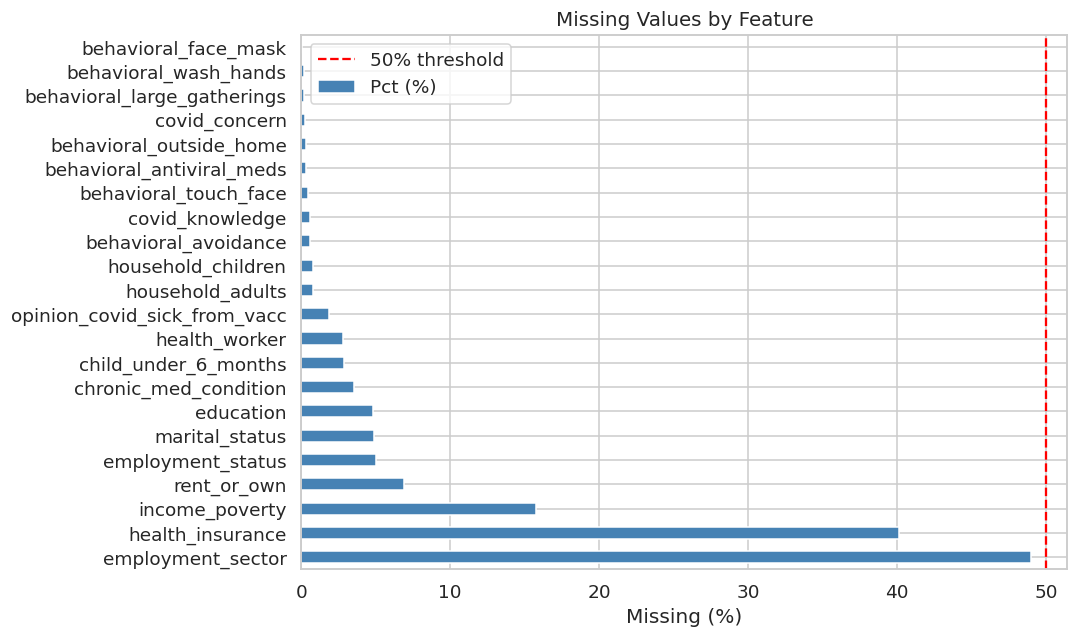

Key observations:
  employment_sector : 49.0% missing — nearly half the dataset
  health_insurance  : 40.1% missing
  income_poverty    : 15.7% missing


In [ ]:
missing = train_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train_raw) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Pct (%)': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0]
display(missing_df)

fig, ax = plt.subplots(figsize=(10, 6))
missing_df['Pct (%)'].plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(50, color='red', linestyle='--', label='50% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Feature')
ax.legend()
plt.tight_layout()
plt.show()

# Key observations
print('Key observations:')
print(f'  employment_sector : {train_raw["employment_sector"].isnull().mean()*100:.1f}% missing — nearly half the dataset')
print(f'  health_insurance  : {train_raw["health_insurance"].isnull().mean()*100:.1f}% missing')
print(f'  income_poverty    : {train_raw["income_poverty"].isnull().mean()*100:.1f}% missing')

## 4.2 Target variable distribution.

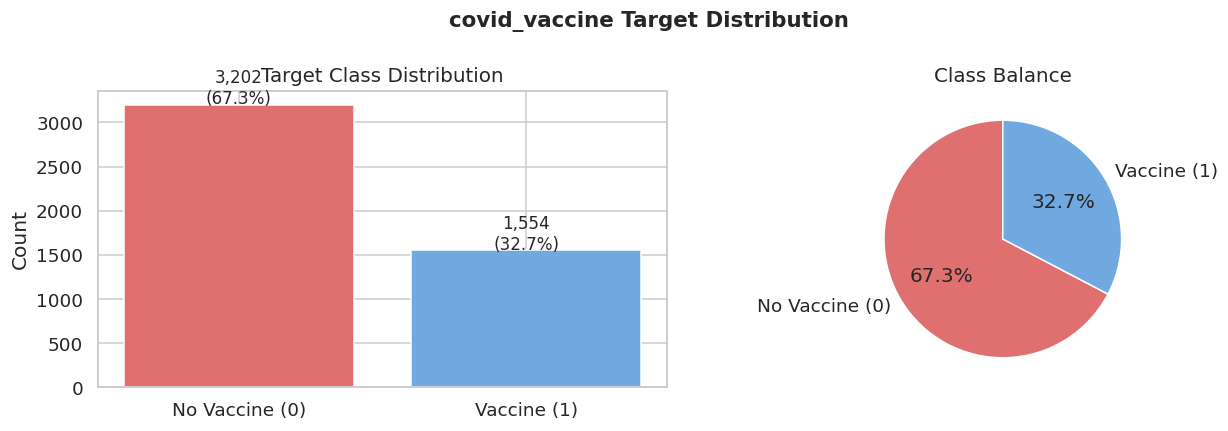

Class balance ratio: 0.485  (1.0 = perfectly balanced)
Imbalance note: ~67% did NOT get the vaccine — use class_weight="balanced"


In [ ]:
vc = train_raw[TARGET_COL].value_counts()
labels = ['No Vaccine (0)', 'Vaccine (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(labels, vc.values, color=['#e07070', '#70a8e0'])
for bar, v in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 10,
                 f'{v:,}\n({v/len(train_raw)*100:.1f}%)',
                 ha='center', fontsize=11)
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%',
            colors=['#e07070','#70a8e0'], startangle=90)
axes[1].set_title('Class Balance')

plt.suptitle('covid_vaccine Target Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

balance = vc.min() / vc.max()
print(f'Class balance ratio: {balance:.3f}  (1.0 = perfectly balanced)')
print(f'Imbalance note: ~{vc[0]/len(train_raw)*100:.0f}% did NOT get the vaccine — use class_weight="balanced"')

# 5. Pre-processing

# 6. Modelling & Cross-Validation Benchmark

# 7. Hyper-parameter Tuning

# 8. Feature Importance

# 9. Explainable AI (XAI) with SHAP

# 10. Submission Files

# 11. Final Summary Dashboard